In [1]:
# PART 1: DATA INGESTION
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:/Users/sivas/OneDrive/Documents/Machine_Learning/laptop_price - dataset.csv')

In [3]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [4]:
df.shape

(1275, 15)

In [5]:
df.describe()

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,2.302980,8.440784,2.040525,1134.969059
std,1.429470,0.503846,5.097809,0.669196,700.752504
min,10.100000,0.900000,2.000000,0.690000,174.000000
25%,14.000000,2.000000,4.000000,1.500000,609.000000
50%,15.600000,2.500000,8.000000,2.040000,989.000000
75%,15.600000,2.700000,8.000000,2.310000,1496.500000
max,18.400000,3.600000,64.000000,4.700000,6099.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), object(10)
me

In [7]:
df.isnull().sum()

Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

#PART 2: EXPLORATORY DATA ANALYSIS (EDA)


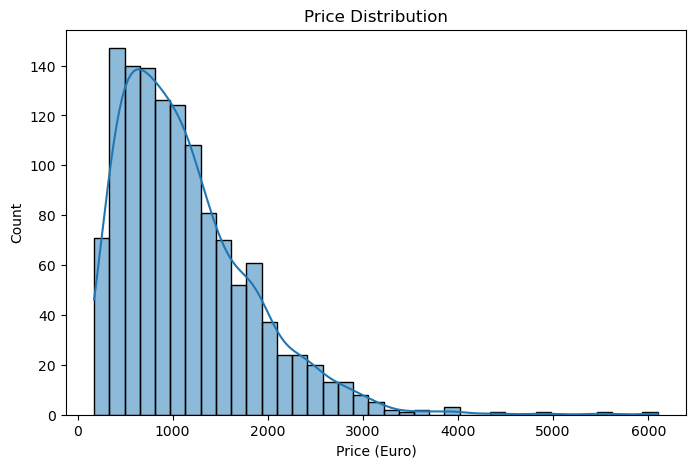

In [9]:
#Price distribution - Univariate analysis
plt.figure(figsize=(8,5))
sns.histplot(df['Price (Euro)'],kde=True)
plt.title("Price Distribution")
plt.show()

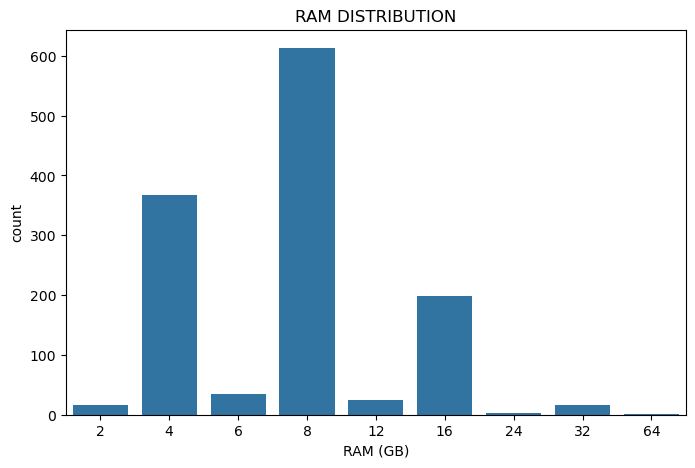

In [10]:
#RAM distribution
plt.figure(figsize=(8,5))
sns.countplot(x="RAM (GB)",data=df)
plt.title("RAM DISTRIBUTION")
plt.show()

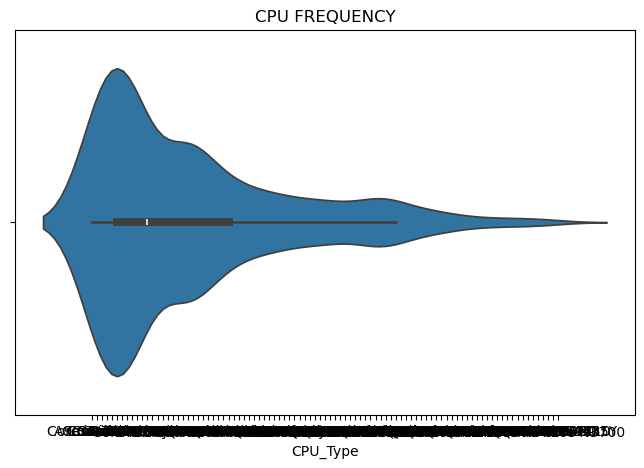

In [11]:
plt.figure(figsize=(8,5))
sns.violinplot(x=df['CPU_Type'])
plt.title("CPU FREQUENCY")
plt.show()

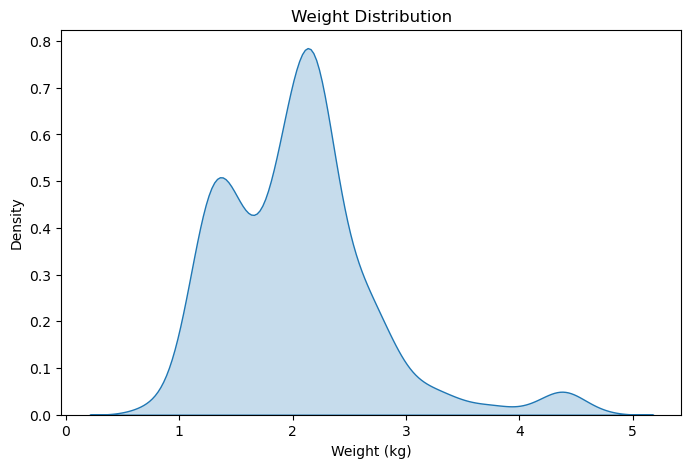

In [12]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["Weight (kg)"],fill=True)
plt.title("Weight Distribution")
plt.show()

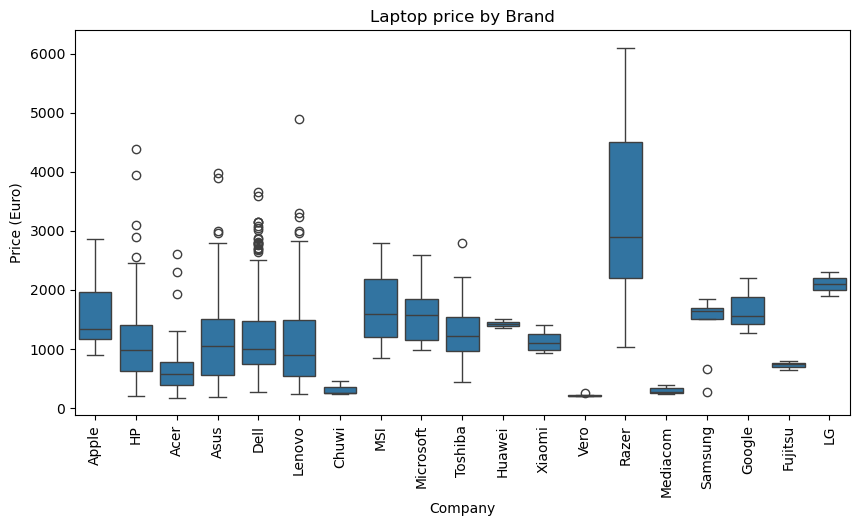

In [13]:
#2.	Bivariate Analysis
#company vs price
plt.figure(figsize=(10,5))
sns.boxplot(x="Company",y="Price (Euro)",data=df)
plt.xticks(rotation = 90)
plt.title("Laptop price by Brand")
plt.show()

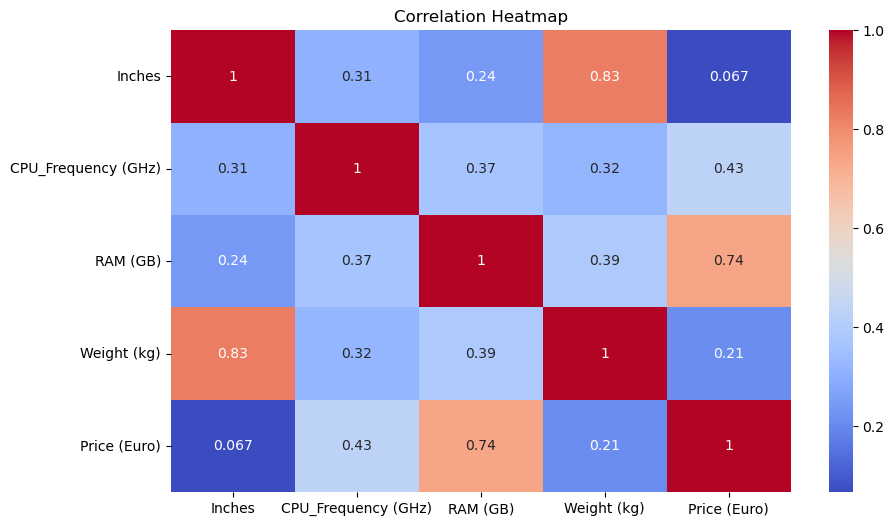

In [14]:
#Heatmap of numerical features
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
#DATA CLEANING
#Memory values are strings like "256GB SSD + 1TB HDD" -> convert to numeric

import re

def process_storage(val):
    items = val.split("+")
    hdd = 0
    ssd = 0
    
    for item in items:
        item = item.strip()
        size = int(re.findall(r'\d+', item)[0])
        
        if "TB" in item:
            size *= 1024
        
        if "HDD" in item:
            hdd += size
        elif "SSD" in item:
            ssd += size
    
    return pd.Series([hdd, ssd])

df[['HDD_GB', 'SSD_GB']] = df['Memory'].apply(process_storage)



In [16]:
#Parse Screen Resolution → PPI(pixel per inch [PPI= diagonal_pixels / screen_size_in_inches]

def extract_ppi(row):
    res = row['ScreenResolution']
    try:
        x, y = res.split("x")
        x = int(x.split()[-1])
        y = int(y)
        inches = row['Inches']
        ppi = ((x**2 + y**2)**0.5) / inches
        return ppi
    except:
        return np.nan

df['PPI'] = df.apply(extract_ppi, axis=1)

    


In [17]:
df.drop(columns=['Memory'],inplace = True)

In [18]:
#Data Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [19]:
#split target & features

X = df.drop(columns=['Price (Euro)'])
y = df['Price (Euro)']

numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
#Preprocessing Pipeline

numeric_transformer = Pipeline([
    ('scaler',StandardScaler())
])

categorical_transformer = Pipeline([
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num',numeric_transformer,numeric_cols),
    ('cat',categorical_transformer,categorical_cols)
])

In [21]:
#Model Building & Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_squared_error

In [22]:
#Helper function to evaluate models

def evaluate_model(model,X_test,y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test,preds)
    rmse = mean_squared_error(y_test,preds)**0.5
    return r2,rmse

In [23]:
#Linear Regression

lr_model = Pipeline([
    ('preprocess',preprocessor),
    ('model',LinearRegression())
])

lr_model.fit(X_train,y_train)
evaluate_model(lr_model,X_test,y_test)
    

(0.815549257411822, 302.5725496589374)

In [24]:
#Decision Tree

dt_model = Pipeline([
    ('preprocess',preprocessor),
    ('model',DecisionTreeRegressor(max_depth=10))
])

dt_model.fit(X_train,y_train)
evaluate_model(dt_model,X_test,y_test)

(0.7920889521938663, 321.2388810291908)

In [25]:
#Random Forest

rf_model = Pipeline([
    ('preprocess',preprocessor),
    ('model',RandomForestRegressor(n_estimators=200,max_depth=15))
])

rf_model.fit(X_train,y_train)
evaluate_model(rf_model,X_test,y_test)


(0.8666939604160768, 257.225626658041)

In [26]:
#Gradient Boosting

gb_model = Pipeline([
    ('preprocess',preprocessor),
    ('model',GradientBoostingRegressor())
])

gb_model.fit(X_train,y_train)
evaluate_model(gb_model,X_test,y_test)

(0.8793814832772766, 244.67878353886533)

In [29]:
#HyperParameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100,200],
    'model__max_depth': [10,15,20]
}

grid = GridSearchCV(
    estimator=Pipeline([
        ('preprocess',preprocessor),
        ('model',RandomForestRegressor())
    ]),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
n_jobs=-1
)

grid.fit(X_train,y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'HDD_GB',
       'SSD_GB', 'PPI'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Company', 'Product', 'TypeName', 'ScreenResolution', 'CPU_Company',
       'CPU_Type', 'GPU_Company', 'GPU_Type', 'OpSys'],
      dtype='object'))])),
                                       ('model', RandomForestRegressor())]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 15, 20],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [31]:
print("Best Params:",grid.best_params_)
best_model = grid.best_estimator_

evaluate_model(best_model,X_test,y_test)

Best Params: {'model__max_depth': 20, 'model__n_estimators': 200}


(0.8695225435080696, 254.48199568754163)

In [32]:
#Feature Importance

#Extracting the feature names after encoding
encoded_features = (
    list(numeric_cols) +
    list(best_model.named_steps['preprocess']
         .named_transformers_['cat']
         .named_steps['ohe']
         .get_feature_names_out(categorical_cols))
)

importances = best_model.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({'Feature':encoded_features,'Importance':importances})
feat_imp.sort_values("Importance",ascending=False).head(20)

,Feature,Importance
2,RAM (GB),0.556706
3,Weight (kg),0.070206
553,TypeName_Notebook,0.055376
1,CPU_Frequency (GHz),0.048397
6,PPI,0.037483
5,SSD_GB,0.026226
0,Inches,0.015204
555,TypeName_Workstation,0.015129
707,GPU_Type_GeForce GTX 1070,0.013070
751,GPU_Type_Quadro M3000M,0.007357


In [36]:
#Final Prediction

sample = X_test.iloc[0:1]
prediction =  best_model.predict(sample)
prediction

array([754.26755573])

In [37]:
#save the model

import pickle

with open("laptop_price_model.pkl","wb") as f:
    pickle.dump(best_model,f)

print("Model saved as laptop_price_model.pkl")

Model saved as laptop_price_model.pkl
